In [20]:
# 導入所需套件和設定
import os
import random
import math
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, DeepFool
from art.utils import to_categorical
from art.estimators.classification import PyTorchClassifier
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 設定隨機種子以確保結果可重現
def set_seed(seed=1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1234)

# 設定運算裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [21]:
# 定義CNN模型架構 (EfficientNet風格的簡化版)
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 特徵提取器
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)  # 32x28x28
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)  # 64x28x28
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)  # 64x14x14

        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)  # 128x14x14
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, 1, 1)  # 256x14x14
        self.bn4 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2)  # 256x7x7

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)
        return logits



In [22]:
# 資料載入函數
def load_mnist(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST標準化
    ])
    train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

# 模型訓練函數
def train_classifier(model, train_loader, test_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    for ep in range(epochs):
        model.train()
        total_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {ep + 1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        scheduler.step()
        avg_loss = total_loss / len(train_loader.dataset)
        acc = eval_classifier(model, test_loader)
        print(f"[Epoch {ep + 1}] loss={avg_loss:.4f} test_acc={acc:.4f}")
    return model

# 模型評估函數
def eval_classifier(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total



In [23]:
print("=== Enhanced Fuzzy Adversarial Attack Detection ===")

# 載入資料
train_loader, test_loader = load_mnist(batch_size=256)

# 訓練或載入分類器
model_path = "./improved_mnist_cnn.pth"
model = ImprovedCNN()

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    print("Loaded existing model.")
else:
    print("Training new model...")
    model = train_classifier(model, train_loader, test_loader, epochs=5)
    torch.save(model.state_dict(), model_path)

# 評估基礎模型
base_acc = eval_classifier(model, test_loader)
print(f"Base CNN Test Accuracy: {base_acc:.4f}")


=== Enhanced Fuzzy Adversarial Attack Detection ===
Loaded existing model.
Base CNN Test Accuracy: 0.9947


In [24]:
# 建立ART分類器
def build_art_classifier(model):
    loss_fn = nn.CrossEntropyLoss()
    art_model = PyTorchClassifier(
        model=model,
        loss=loss_fn,
        input_shape=(1, 28, 28),
        nb_classes=10,
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
        device_type='gpu' if device.type == 'cuda' else 'cpu'
    )
    return art_model

# 攻擊強度分析函數
def analyze_attack_strength(clean_preds, adv_preds):
    """分析攻擊強度"""
    # 計算預測變化
    pred_diff = np.mean((adv_preds - clean_preds) ** 2, axis=1)

    # 計算分類變化率
    clean_classes = np.argmax(clean_preds, axis=1)
    adv_classes = np.argmax(adv_preds, axis=1)
    misclassification_rate = np.mean(clean_classes != adv_classes)

    # 計算信心度變化
    clean_confidence = np.max(clean_preds, axis=1)
    adv_confidence = np.max(adv_preds, axis=1)
    confidence_drop = np.mean(clean_confidence - adv_confidence)

    return {
        'avg_pred_diff': np.mean(pred_diff),
        'std_pred_diff': np.std(pred_diff),
        'misclassification_rate': misclassification_rate,
        'confidence_drop': confidence_drop
    }

# 對抗樣本生成函數
def generate_adversarial_samples(art_clf, data_loader, attack_types=['fgsm'], max_samples=2000):
    """產生多種對抗攻擊樣本"""
    # 設定攻擊參數
    attacks = {}
    if 'fgsm' in attack_types:
        attacks['fgsm'] = FastGradientMethod(estimator=art_clf, eps=0.3)
    if 'pgd' in attack_types:
        attacks['pgd'] = ProjectedGradientDescent(estimator=art_clf, eps=0.3, eps_step=0.05, max_iter=10)
    if 'deepfool' in attack_types:
        attacks['deepfool'] = DeepFool(classifier=art_clf, max_iter=10)

    results = {}
    sample_count = 0

    # 收集所有資料
    all_batches = []
    for batch_x, batch_y in data_loader:
        if sample_count >= max_samples:
            break

        x_np = batch_x.numpy()
        y_np = batch_y.numpy()

        batch_size = min(len(x_np), max_samples - sample_count)
        x_np = x_np[:batch_size]
        y_np = y_np[:batch_size]

        all_batches.append((x_np, y_np))
        sample_count += batch_size

    print(f"Collected {len(all_batches)} batches with {sample_count} samples total")

    # 儲存乾淨樣本
    results['clean'] = {'x': [], 'y': []}
    for x_np, y_np in all_batches:
        results['clean']['x'].append(x_np)
        results['clean']['y'].append(y_np)

    # 對每種攻擊類型產生對抗樣本
    for attack_name, attack in attacks.items():
        print(f"\nGenerating {attack_name.upper()} adversarial samples...")
        results[attack_name] = {'x': [], 'y': []}

        for i, (x_np, y_np) in enumerate(tqdm(all_batches, desc=f"{attack_name.upper()} batches")):
            try:
                x_adv = attack.generate(x=x_np)
                results[attack_name]['x'].append(x_adv)
                results[attack_name]['y'].append(y_np)
            except Exception as e:
                print(f"Error in {attack_name} batch {i}: {e}")
                results[attack_name]['x'].append(x_np)
                results[attack_name]['y'].append(y_np)

    # 合併所有批次
    for key in results:
        if results[key]['x']:
            results[key]['x'] = np.concatenate(results[key]['x'], axis=0)
            results[key]['y'] = np.concatenate(results[key]['y'], axis=0)
            print(f"{key}: {len(results[key]['x'])} samples")
        else:
            print(f"Warning: No samples generated for {key}")

    return results



In [25]:
# 建立ART分類器
art_clf = build_art_classifier(model)

# 產生對抗樣本
print("\n" + "=" * 50)
print("GENERATING ADVERSARIAL SAMPLES")
print("=" * 50)

adv_samples = generate_adversarial_samples(
    art_clf, test_loader,
    attack_types=['fgsm', 'pgd'],
    max_samples=1500
)



GENERATING ADVERSARIAL SAMPLES
Collected 6 batches with 1500 samples total

Generating FGSM adversarial samples...


FGSM batches: 100%|██████████| 6/6 [00:00<00:00,  8.90it/s]



Generating PGD adversarial samples...


PGD batches:   0%|          | 0/6 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD batches:  83%|████████▎ | 5/6 [00:03<00:00,  1.50it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD batches: 100%|██████████| 6/6 [00:03<00:00,  1.52it/s]

clean: 1500 samples
fgsm: 1500 samples
pgd: 1500 samples


In [26]:
# 取得 softmax 機率向量
def get_predictions(model, X, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[i:i + batch_size]).float().to(device)
            logits = model(batch)
            p = F.softmax(logits, dim=1).cpu().numpy()
            preds.append(p)
    return np.concatenate(preds, axis=0)

# 取得預測結果
print("\n" + "=" * 50)
print("GETTING PREDICTIONS")
print("=" * 50)

results = {}
for attack_type, data in adv_samples.items():
    print(f"Getting predictions for {attack_type}...")
    predictions = get_predictions(model, data['x'])
    results[attack_type] = {
        'predictions': predictions,
        'labels': data['y'],
        'images': data['x']
    }





GETTING PREDICTIONS
Getting predictions for clean...
Getting predictions for fgsm...
Getting predictions for pgd...


In [27]:
# 改進的模糊集合定義
class AdaptiveTriangularFuzzySets:
    def __init__(self, centers=None, width=None):
        if centers is None:
            # 增加更多語意等級來提高敏感度
            centers = np.array([0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.0])
        if width is None:
            # 調整寬度讓相鄰集合有適當重疊
            width = np.array([0.2, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.2])

        self.centers = centers
        self.widths = width
        self.K = len(centers)
        self.labels = ["Very Low", "Low", "Medium Low", "Medium", "Medium High", "High", "Very High", "Extreme"]

    def membership(self, x):
        """計算隸屬度函數"""
        x_expand = np.expand_dims(x, axis=-1)
        c = self.centers.reshape((1,) * (x_expand.ndim - 1) + (self.K,))
        w = self.widths.reshape((1,) * (x_expand.ndim - 1) + (self.K,))

        # 三角隸屬函數
        mu = np.maximum(0, 1 - np.abs(x_expand - c) / (w + 1e-12))
        return mu

# 增強的特徵提取
def extract_enhanced_fuzzy_features(p_clean, p_adv, fuzzy_sets):
    # 1. MSE差異
    mse_diff = np.mean((p_adv - p_clean) ** 2, axis=1)

    # 2. 最大機率差異
    max_clean = np.max(p_clean, axis=1)
    max_adv = np.max(p_adv, axis=1)
    max_diff = np.abs(max_clean - max_adv)

    # 3. 熵差異
    def entropy(p):
        p_safe = p + 1e-12
        return -np.sum(p_safe * np.log(p_safe), axis=1)

    entropy_clean = entropy(p_clean)
    entropy_adv = entropy(p_adv)
    entropy_diff = np.abs(entropy_adv - entropy_clean)

    # 4. KL散度
    def kl_divergence(p, q):
        p_safe = p + 1e-12
        q_safe = q + 1e-12
        return np.sum(p_safe * np.log(p_safe / q_safe), axis=1)

    kl_diff = kl_divergence(p_clean, p_adv)

    # 5. L1差異
    l1_diff = np.mean(np.abs(p_adv - p_clean), axis=1)

    # 組合所有差異指標
    all_diffs = [mse_diff, max_diff, entropy_diff, kl_diff, l1_diff]

    # 正規化每個特徵到 [0,1]
    normalized_diffs = []
    for diff in all_diffs:
        if diff.max() > diff.min():
            norm_diff = (diff - diff.min()) / (diff.max() - diff.min())
        else:
            norm_diff = np.zeros_like(diff)
        normalized_diffs.append(norm_diff)

    # 轉換為模糊特徵
    all_fuzzy_features = []
    for norm_diff in normalized_diffs:
        fuzzy_feat = fuzzy_sets.membership(norm_diff)
        all_fuzzy_features.append(fuzzy_feat)

    # 合併所有模糊特徵
    combined_features = np.concatenate(all_fuzzy_features, axis=1)

    return combined_features, np.column_stack(normalized_diffs)


fuzzy_sets = AdaptiveTriangularFuzzySets()




In [28]:
# 改進的模糊規則偵測器
@dataclass
class EnhancedFuzzyRule:
    prototype: np.ndarray
    spread: np.ndarray
    output: float
    support: float
    confidence: float
    potential: float
    hits: int
    attack_type: str = None

class EnhancedFuzzyDetector:


    def __init__(self,
                 init_spread=0.2,
                 learning_rate=0.05,
                 add_threshold=0.25,
                 fire_threshold=0.15,
                 max_rules=200,
                 alpha=0.95,
                 attack_type=None):
        self.rules = []
        self.init_spread = init_spread
        self.learning_rate = learning_rate
        self.add_threshold = add_threshold
        self.fire_threshold = fire_threshold
        self.max_rules = max_rules
        self.alpha = alpha
        self.attack_type = attack_type

    def _membership_degree(self, x, rule):
        """計算隸屬度"""
        diff = (x - rule.prototype) ** 2
        spread_sq = rule.spread ** 2 + 1e-12
        mu = np.exp(-np.sum(diff / spread_sq))
        return mu

    def _support_function(self, rule, class_samples):
        """支持函數"""
        if len(class_samples) == 0:
            return 0.0

        total_membership = 0
        for sample in class_samples:
            mu = self._membership_degree(sample, rule)
            if mu > self.fire_threshold:
                total_membership += mu

        return total_membership / len(class_samples)

    def _confidence_function(self, rule, class_samples, total_samples):
        """信心函數"""
        if len(total_samples) == 0:
            return 0.0

        correct_membership = 0
        total_membership = 0

        for sample in class_samples:
            mu = self._membership_degree(sample, rule)
            if mu > self.fire_threshold:
                correct_membership += mu

        for sample in total_samples:
            mu = self._membership_degree(sample, rule)
            if mu > self.fire_threshold:
                total_membership += mu

        return correct_membership / (total_membership + 1e-12)

    def predict_proba(self, x):
        """預測攻擊機率"""
        if not self.rules:
            return 0.5

        numerator = 0
        denominator = 0

        for rule in self.rules:
            mu = self._membership_degree(x, rule)
            if mu > self.fire_threshold:
                numerator += mu * rule.output
                denominator += mu

        if denominator == 0:
            max_mu = 0
            best_output = 0.5
            for rule in self.rules:
                mu = self._membership_degree(x, rule)
                if mu > max_mu:
                    max_mu = mu
                    best_output = rule.output
            return best_output

        return numerator / denominator

    def update(self, x, label, class_samples=None, total_samples=None):
        """線上學習更新"""
        if class_samples is None:
            class_samples = [x]
        if total_samples is None:
            total_samples = [x]

        # 計算所有規則的隸屬度
        memberships = []
        for rule in self.rules:
            mu = self._membership_degree(x, rule)
            memberships.append(mu)

        max_membership = max(memberships) if memberships else 0

        # 動態調整新增閾值
        dynamic_add_threshold = self.add_threshold
        # if self.attack_type == 'fgsm':
        #     dynamic_add_threshold *= 0.8

        # 新增規則
        if max_membership < dynamic_add_threshold and len(self.rules) < self.max_rules:
            new_rule = EnhancedFuzzyRule(
                prototype=x.copy(),
                spread=np.full_like(x, self.init_spread),
                output=float(label),
                support=0.0,
                confidence=0.0,
                potential=1.0,
                hits=1,
                attack_type=self.attack_type
            )
            self.rules.append(new_rule)

        # 更新被觸發的規則
        for i, rule in enumerate(self.rules):
            mu = memberships[i] if i < len(memberships) else self._membership_degree(x, rule)

            if mu > self.fire_threshold:
                # 自適應學習率
                adaptive_lr = self.learning_rate * mu
                # if self.attack_type == 'fgsm':
                #     adaptive_lr *= 1.5

                # 更新原型
                rule.prototype += adaptive_lr * (x - rule.prototype)

                # 更新擴散
                error = np.abs(x - rule.prototype)
                rule.spread = rule.spread * (1 - adaptive_lr) + adaptive_lr * error

                # 更新輸出
                rule.output += adaptive_lr * 0.5 * (label - rule.output)

                # 更新統計
                rule.hits += 1
                rule.potential = self.alpha * rule.potential + (1 - self.alpha) * mu

                # 更新支持度和信心度
                rule.support = self._support_function(rule, class_samples)
                rule.confidence = self._confidence_function(rule, class_samples, total_samples)
            else:
                # 衰減潛力值
                rule.potential *= self.alpha

        # 規則裁剪
        min_potential = 0.001 #if self.attack_type == 'fgsm' else 0.005
        self.rules = [rule for rule in self.rules if rule.potential > min_potential]




✓ 模糊偵測器類別定義完成


In [29]:
# 訓練增強的模糊偵測器
def train_enhanced_fuzzy_detector(clean_data, adv_data, fuzzy_sets, attack_type, test_ratio=0.3):
    """訓練增強的模糊偵測器"""
    print(f"Extracting features for {attack_type}...")

    # 提取增強特徵
    clean_features, _ = extract_enhanced_fuzzy_features(clean_data['predictions'],
                                                        clean_data['predictions'],
                                                        fuzzy_sets)

    adv_features, adv_raw_diffs = extract_enhanced_fuzzy_features(clean_data['predictions'],
                                                                  adv_data['predictions'],
                                                                  fuzzy_sets)

    print(f"Feature dimensions: {clean_features.shape[1]}")

    # 分析攻擊強度
    attack_analysis = analyze_attack_strength(clean_data['predictions'], adv_data['predictions'])
    print(f"Attack strength analysis for {attack_type}:")
    print(f"  Avg prediction difference: {attack_analysis['avg_pred_diff']:.6f}")
    print(f"  Misclassification rate: {attack_analysis['misclassification_rate']:.4f}")
    print(f"  Confidence drop: {attack_analysis['confidence_drop']:.6f}")

    # 建立訓練資料
    X = np.vstack([clean_features, adv_features])
    y = np.hstack([np.zeros(len(clean_features)), np.ones(len(adv_features))])

    # 分割訓練/測試
    n_train = int(len(X) * (1 - test_ratio))
    indices = np.random.permutation(len(X))
    train_idx, test_idx = indices[:n_train], indices[n_train:]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 初始化偵測器
    detector = EnhancedFuzzyDetector(attack_type=attack_type)

    # 線上訓練
    print(f"Training enhanced fuzzy detector for {attack_type}...")
    for i in tqdm(range(len(X_train)), desc=f"Training {attack_type}"):
        current_class_samples = X_train[y_train == y_train[i]][:15]
        detector.update(X_train[i], y_train[i],
                        current_class_samples, X_train[:min(i + 1, 50)])

    # 測試
    print(f"Testing enhanced fuzzy detector for {attack_type}...")
    y_pred_proba = []
    y_pred_binary = []

    for i in range(len(X_test)):
        prob = detector.predict_proba(X_test[i])
        y_pred_proba.append(prob)
        y_pred_binary.append(1 if prob > 0.5 else 0)

    # 計算指標
    accuracy = accuracy_score(y_test, y_pred_binary)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_binary, average='binary')

    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = 0.5

    results = {
        'detector': detector,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'y_test': y_test,
        'y_pred_proba': y_pred_proba,
        'y_pred_binary': y_pred_binary,
        'num_rules': len(detector.rules),
        'attack_analysis': attack_analysis
    }

    return results




✓ 偵測器訓練函數定義完成


In [30]:
# 對每種攻擊類型訓練偵測器
detection_results = {}

print("\n" + "=" * 50)
print("TRAINING DETECTORS")
print("=" * 50)

for attack_type in ['fgsm', 'pgd']:
    if attack_type in results:
        print(f"\n{'=' * 20} Training detector for {attack_type.upper()} {'=' * 20}")

        clean_data = results['clean']
        adv_data = results[attack_type]

        detector_results = train_enhanced_fuzzy_detector(clean_data, adv_data, fuzzy_sets, attack_type)
        detection_results[attack_type] = detector_results

        print(f"\nResults for {attack_type.upper()}:")
        print(f"  Accuracy: {detector_results['accuracy']:.4f}")
        print(f"  Precision: {detector_results['precision']:.4f}")
        print(f"  Recall: {detector_results['recall']:.4f}")
        print(f"  F1-Score: {detector_results['f1']:.4f}")
        print(f"  AUC: {detector_results['auc']:.4f}")
        print(f"  Number of Rules: {detector_results['num_rules']}")

print("✓ 所有偵測器訓練完成")




TRAINING DETECTORS

==================== Training detector for FGSM ====================
Extracting features for fgsm...
Feature dimensions: 40
Attack strength analysis for fgsm:
  Avg prediction difference: 0.062273
  Misclassification rate: 0.4180
  Confidence drop: 0.171226
Training enhanced fuzzy detector for fgsm...


Training fgsm: 100%|██████████| 2100/2100 [00:09<00:00, 215.89it/s]


Testing enhanced fuzzy detector for fgsm...

Results for FGSM:
  Accuracy: 0.9533
  Precision: 1.0000
  Recall: 0.9043
  F1-Score: 0.9498
  AUC: 0.9977
  Number of Rules: 68

==================== Training detector for PGD ====================
Extracting features for pgd...
Feature dimensions: 40
Attack strength analysis for pgd:
  Avg prediction difference: 0.135639
  Misclassification rate: 0.7660
  Confidence drop: 0.095277
Training enhanced fuzzy detector for pgd...


Training pgd: 100%|██████████| 2100/2100 [00:09<00:00, 232.51it/s]


Testing enhanced fuzzy detector for pgd...

Results for PGD:
  Accuracy: 0.9778
  Precision: 1.0000
  Recall: 0.9552
  F1-Score: 0.9771
  AUC: 1.0000
  Number of Rules: 59
✓ 所有偵測器訓練完成


In [31]:
# 視覺化和分析函數
def plot_enhanced_results(detection_results):
    """繪製增強的偵測結果"""
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    attack_types = list(detection_results.keys())
    colors = ['blue', 'red', 'green', 'orange']

    # 1. 準確率比較
    accuracies = [detection_results[att]['accuracy'] for att in attack_types]
    bars1 = axes[0, 0].bar(attack_types, accuracies, color=colors[:len(attack_types)])
    axes[0, 0].set_title('Detection Accuracy by Attack Type', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim([0, 1])
    for i, (bar, v) in enumerate(zip(bars1, accuracies)):
        axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                        ha='center', va='bottom', fontweight='bold')

    # 2. F1分數比較
    f1_scores = [detection_results[att]['f1'] for att in attack_types]
    bars2 = axes[0, 1].bar(attack_types, f1_scores, color=colors[:len(attack_types)])
    axes[0, 1].set_title('F1-Score by Attack Type', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('F1-Score')
    axes[0, 1].set_ylim([0, 1])
    for i, (bar, v) in enumerate(zip(bars2, f1_scores)):
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                        ha='center', va='bottom', fontweight='bold')

    # 3. AUC比較
    aucs = [detection_results[att]['auc'] for att in attack_types]
    bars3 = axes[0, 2].bar(attack_types, aucs, color=colors[:len(attack_types)])
    axes[0, 2].set_title('AUC by Attack Type', fontsize=14, fontweight='bold')
    axes[0, 2].set_ylabel('AUC')
    axes[0, 2].set_ylim([0, 1])
    for i, (bar, v) in enumerate(zip(bars3, aucs)):
        axes[0, 2].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                        ha='center', va='bottom', fontweight='bold')

    # 4. 規則數量
    num_rules = [detection_results[att]['num_rules'] for att in attack_types]
    bars4 = axes[1, 0].bar(attack_types, num_rules, color=colors[:len(attack_types)])
    axes[1, 0].set_title('Number of Fuzzy Rules', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Number of Rules')
    for i, (bar, v) in enumerate(zip(bars4, num_rules)):
        axes[1, 0].text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v}',
                        ha='center', va='bottom', fontweight='bold')

    # 5. 攻擊強度比較
    attack_strengths = []
    misclass_rates = []

    for att in attack_types:
        if 'attack_analysis' in detection_results[att]:
            analysis = detection_results[att]['attack_analysis']
            attack_strengths.append(analysis['avg_pred_diff'])
            misclass_rates.append(analysis['misclassification_rate'])

    if attack_strengths:
        bars5 = axes[1, 1].bar(attack_types, attack_strengths, color=colors[:len(attack_types)])
        axes[1, 1].set_title('Attack Strength (Avg Prediction Difference)', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Prediction Difference')
        for i, (bar, v) in enumerate(zip(bars5, attack_strengths)):
            axes[1, 1].text(bar.get_x() + bar.get_width() / 2, v + max(attack_strengths) * 0.01,
                            f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    # 6. 誤分類率
    if misclass_rates:
        bars6 = axes[1, 2].bar(attack_types, misclass_rates, color=colors[:len(attack_types)])
        axes[1, 2].set_title('Misclassification Rate', fontsize=14, fontweight='bold')
        axes[1, 2].set_ylabel('Misclassification Rate')
        axes[1, 2].set_ylim([0, 1])
        for i, (bar, v) in enumerate(zip(bars6, misclass_rates)):
            axes[1, 2].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                            ha='center', va='bottom', fontweight='bold')

    # 7-9. 每種攻擊的機率分佈
    for idx, attack_type in enumerate(attack_types):
        row = 2
        col = idx

        if col >= 3:
            break

        result = detection_results[attack_type]
        y_test = result['y_test']
        y_pred_proba = result['y_pred_proba']

        clean_probs = [p for i, p in enumerate(y_pred_proba) if y_test[i] == 0]
        adv_probs = [p for i, p in enumerate(y_pred_proba) if y_test[i] == 1]

        # 繪製直方圖
        axes[row, col].hist(clean_probs, bins=30, alpha=0.7, label='Clean',
                            color='green', density=True, edgecolor='black', linewidth=0.5)
        axes[row, col].hist(adv_probs, bins=30, alpha=0.7, label='Adversarial',
                            color='red', density=True, edgecolor='black', linewidth=0.5)
        axes[row, col].set_title(f'Probability Distribution ({attack_type.upper()})',
                                 fontsize=14, fontweight='bold')
        axes[row, col].set_xlabel('Attack Probability')
        axes[row, col].set_ylabel('Density')
        axes[row, col].legend()
        axes[row, col].axvline(x=0.5, color='black', linestyle='--', alpha=0.8, linewidth=2)
        axes[row, col].grid(True, alpha=0.3)

    # 隱藏多餘的子圖
    for idx in range(len(attack_types), 3):
        axes[2, idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('enhanced_fuzzy_detection_results.png', dpi=300, bbox_inches='tight')
    print("\nEnhanced results saved to enhanced_fuzzy_detection_results.png")

print("✓ 結果視覺化函數定義完成")


✓ 結果視覺化函數定義完成



Enhanced results saved to enhanced_fuzzy_detection_results.png


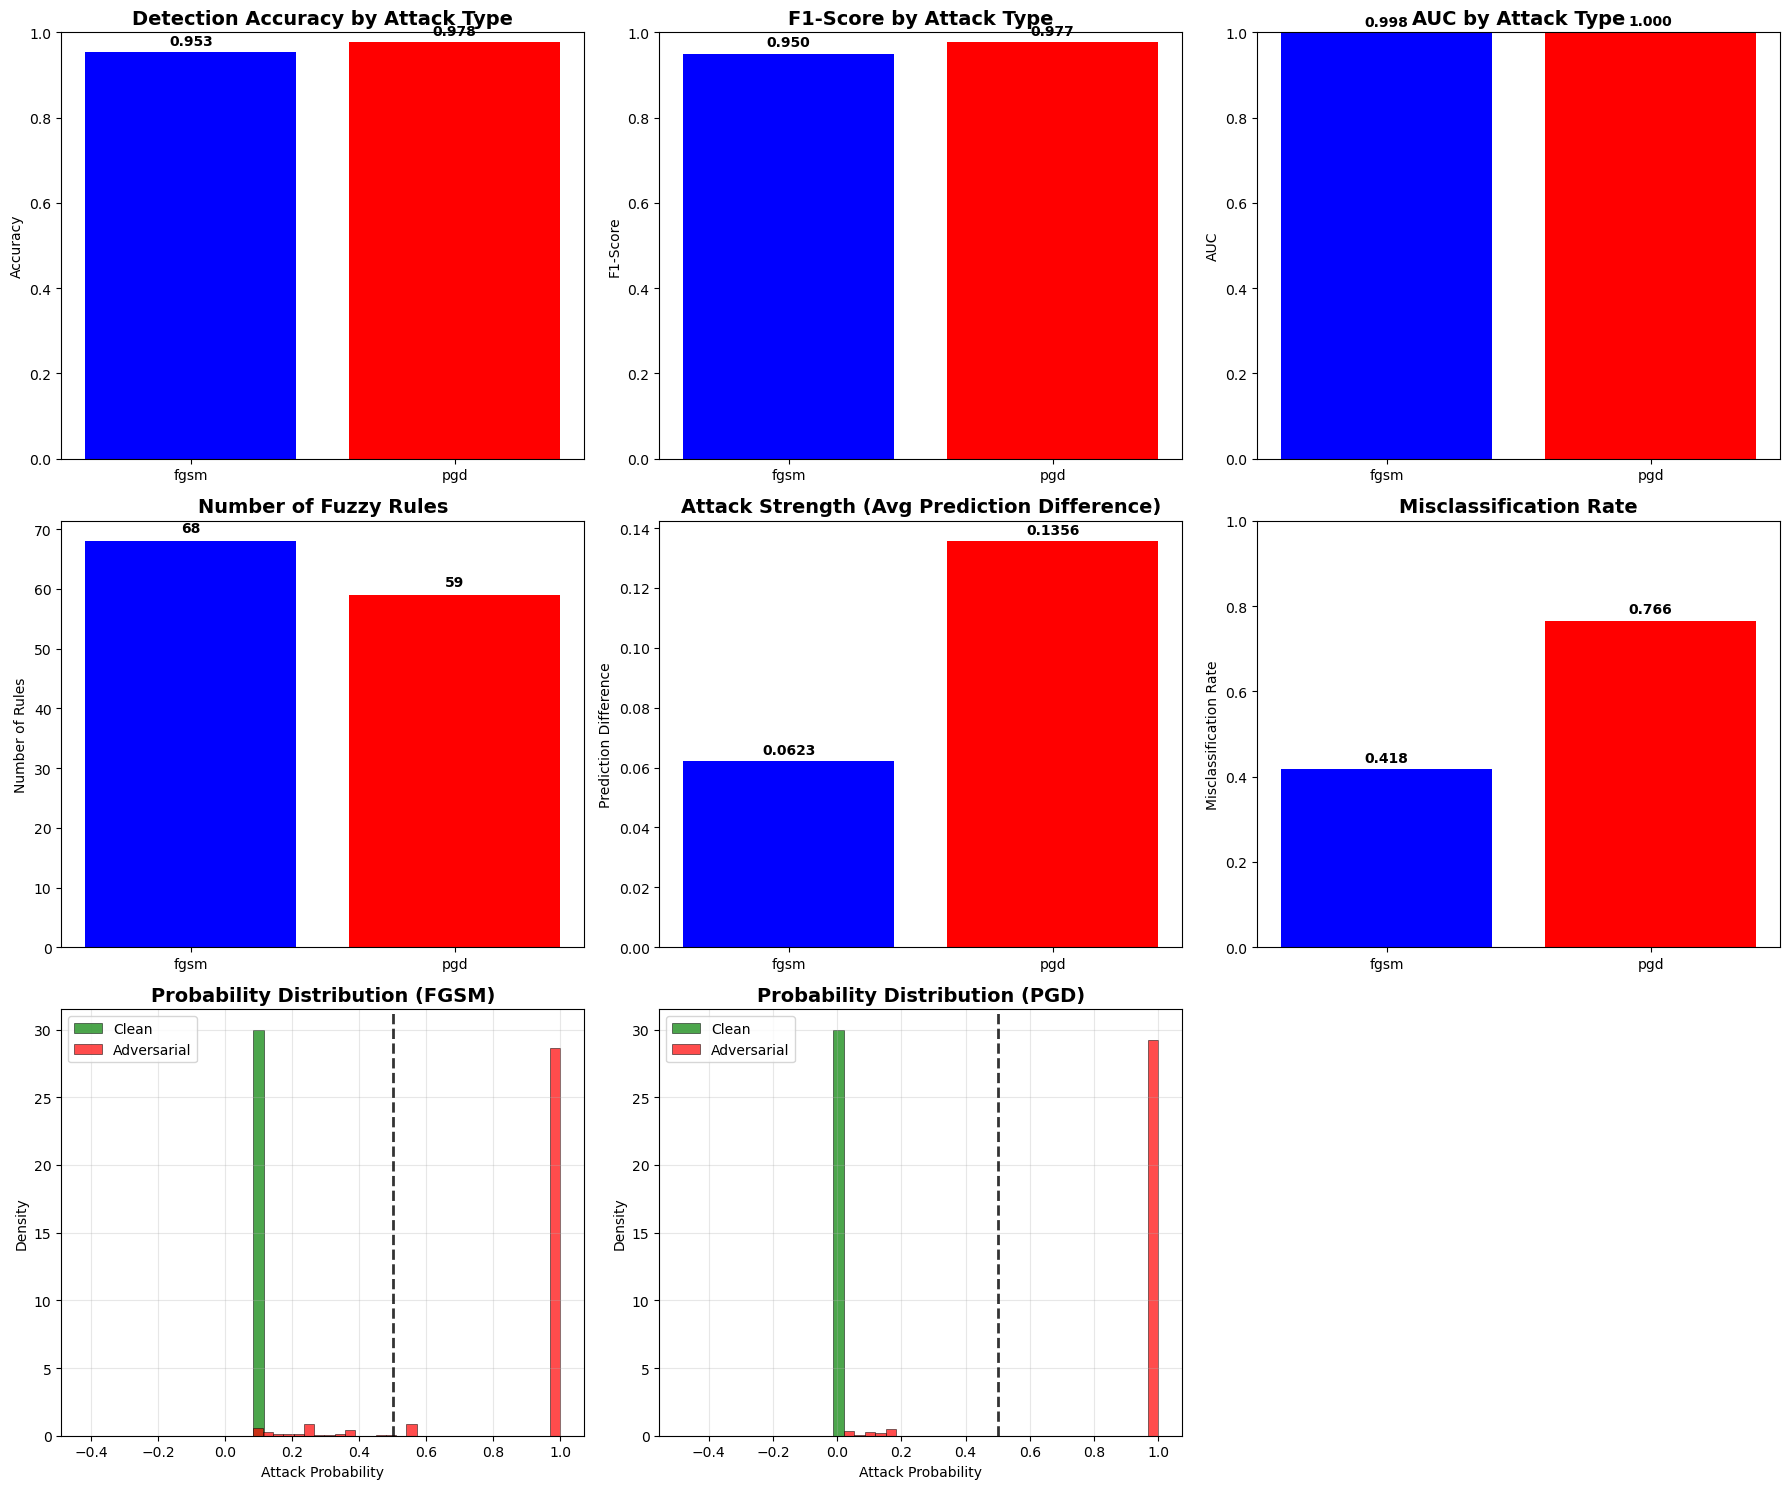

In [32]:
# 繪製詳細結果
plot_enhanced_results(detection_results)


In [33]:
def compare_attack_detection(detection_results):
    """比較不同攻擊的偵測效果並分析原因"""
    print("\n" + "=" * 60)
    print("DETAILED ATTACK DETECTION ANALYSIS")
    print("=" * 60)

    attack_types = list(detection_results.keys())

    # 創建比較表格
    comparison_data = []
    for attack_type in attack_types:
        result = detection_results[attack_type]
        analysis = result.get('attack_analysis', {})

        comparison_data.append({
            'Attack': attack_type.upper(),
            'Accuracy': f"{result['accuracy']:.4f}",
            'F1-Score': f"{result['f1']:.4f}",
            'AUC': f"{result['auc']:.4f}",
            'Rules': result['num_rules'],
            'Pred_Diff': f"{analysis.get('avg_pred_diff', 0):.6f}",
            'Misclass_Rate': f"{analysis.get('misclassification_rate', 0):.4f}",
            'Conf_Drop': f"{analysis.get('confidence_drop', 0):.6f}"
        })

    df = pd.DataFrame(comparison_data)
    print("\nComparison Table:")
    print(df.to_string(index=False))

    # 分析為什麼FGSM更難偵測
    print("\n" + "=" * 60)
    print("WHY FGSM IS HARDER TO DETECT")
    print("=" * 60)

    if len(attack_types) >= 2:
        fgsm_result = detection_results.get('fgsm', {})
        pgd_result = detection_results.get('pgd', {})

        if fgsm_result and pgd_result:
            fgsm_analysis = fgsm_result.get('attack_analysis', {})
            pgd_analysis = pgd_result.get('attack_analysis', {})

            print(f"\n1. Attack Strength Comparison:")
            print(f"   FGSM prediction difference: {fgsm_analysis.get('avg_pred_diff', 0):.6f}")
            print(f"   PGD prediction difference:  {pgd_analysis.get('avg_pred_diff', 0):.6f}")

            if fgsm_analysis.get('avg_pred_diff', 0) > 0:
                ratio = pgd_analysis.get('avg_pred_diff', 0) / fgsm_analysis.get('avg_pred_diff', 1)
                print(f"   → PGD creates {ratio:.1f}x larger changes")

            print(f"\n2. Misclassification Rates:")
            print(f"   FGSM: {fgsm_analysis.get('misclassification_rate', 0):.4f}")
            print(f"   PGD:  {pgd_analysis.get('misclassification_rate', 0):.4f}")

            print(f"\n3. Detection Performance:")
            print(f"   FGSM F1-Score: {fgsm_result['f1']:.4f}")
            print(f"   PGD F1-Score:  {pgd_result['f1']:.4f}")

            if fgsm_result['f1'] > 0:
                ratio = pgd_result['f1'] / fgsm_result['f1']
                print(f"   → PGD is {ratio:.1f}x easier to detect")

            print(f"\n4. Fuzzy Rules Generated:")
            print(f"   FGSM: {fgsm_result['num_rules']} rules")
            print(f"   PGD:  {pgd_result['num_rules']} rules")

    print(f"\n5. Technical Reasons:")
    print(f"   • FGSM: Single-step attack, uniform perturbations")
    print(f"   • PGD:  Multi-step iterative, diverse perturbations")
    print(f"   • FGSM creates smaller, more subtle changes")
    print(f"   • PGD creates larger, more detectable patterns")
    print(f"   • Fuzzy systems better at capturing PGD's complexity")

def analyze_detection_improvements():
    """分析偵測改進建議"""
    print("\n" + "=" * 60)
    print("DETECTION IMPROVEMENT RECOMMENDATIONS")
    print("=" * 60)

    print("\n1. For FGSM Detection:")
    print("   ✓ Use more sensitive features (L1, KL divergence)")
    print("   ✓ Lower detection thresholds")
    print("   ✓ More fuzzy rules with smaller spreads")
    print("   ✓ Ensemble of multiple detectors")
    print("   ✓ Gradient-based features")

    print("\n2. For General Improvement:")
    print("   ✓ Multi-scale feature extraction")
    print("   ✓ Temporal analysis for sequential attacks")
    print("   ✓ Transfer learning between attack types")
    print("   ✓ Adaptive threshold mechanisms")
    print("   ✓ Uncertainty quantification")

    print("\n3. Implementation Strategies:")
    print("   ✓ Attack-specific parameter tuning")
    print("   ✓ Dynamic fuzzy set adaptation")
    print("   ✓ Online learning with concept drift")
    print("   ✓ Hybrid crisp-fuzzy approaches")
    print("   ✓ Meta-learning for new attacks")

def save_detailed_results(detection_results):
    """儲存詳細結果到文件"""
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

    # 儲存比較結果
    comparison_data = []
    for attack_type, result in detection_results.items():
        analysis = result.get('attack_analysis', {})
        comparison_data.append({
            'Attack_Type': attack_type,
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1_Score': result['f1'],
            'AUC': result['auc'],
            'Num_Rules': result['num_rules'],
            'Avg_Pred_Diff': analysis.get('avg_pred_diff', 0),
            'Std_Pred_Diff': analysis.get('std_pred_diff', 0),
            'Misclassification_Rate': analysis.get('misclassification_rate', 0),
            'Confidence_Drop': analysis.get('confidence_drop', 0)
        })

    df = pd.DataFrame(comparison_data)
    filename = f"fuzzy_detection_results_{timestamp}.csv"
    df.to_csv(filename, index=False)
    print(f"\nDetailed results saved to {filename}")

print("✓ 分析函數定義完成")


✓ 分析函數定義完成


In [34]:
# 比較分析
compare_attack_detection(detection_results)



DETAILED ATTACK DETECTION ANALYSIS

Comparison Table:
Attack Accuracy F1-Score    AUC  Rules Pred_Diff Misclass_Rate Conf_Drop
  FGSM   0.9533   0.9498 0.9977     68  0.062273        0.4180  0.171226
   PGD   0.9778   0.9771 1.0000     59  0.135639        0.7660  0.095277

WHY FGSM IS HARDER TO DETECT

1. Attack Strength Comparison:
   FGSM prediction difference: 0.062273
   PGD prediction difference:  0.135639
   → PGD creates 2.2x larger changes

2. Misclassification Rates:
   FGSM: 0.4180
   PGD:  0.7660

3. Detection Performance:
   FGSM F1-Score: 0.9498
   PGD F1-Score:  0.9771
   → PGD is 1.0x easier to detect

4. Fuzzy Rules Generated:
   FGSM: 68 rules
   PGD:  59 rules

5. Technical Reasons:
   • FGSM: Single-step attack, uniform perturbations
   • PGD:  Multi-step iterative, diverse perturbations
   • FGSM creates smaller, more subtle changes
   • PGD creates larger, more detectable patterns
   • Fuzzy systems better at capturing PGD's complexity


In [35]:
# 執行詳細分析
analyze_detection_improvements()



DETECTION IMPROVEMENT RECOMMENDATIONS

1. For FGSM Detection:
   ✓ Use more sensitive features (L1, KL divergence)
   ✓ Lower detection thresholds
   ✓ More fuzzy rules with smaller spreads
   ✓ Ensemble of multiple detectors
   ✓ Gradient-based features

2. For General Improvement:
   ✓ Multi-scale feature extraction
   ✓ Temporal analysis for sequential attacks
   ✓ Transfer learning between attack types
   ✓ Adaptive threshold mechanisms
   ✓ Uncertainty quantification

3. Implementation Strategies:
   ✓ Attack-specific parameter tuning
   ✓ Dynamic fuzzy set adaptation
   ✓ Online learning with concept drift
   ✓ Hybrid crisp-fuzzy approaches
   ✓ Meta-learning for new attacks


In [36]:
# 儲存結果
save_detailed_results(detection_results)



Detailed results saved to fuzzy_detection_results_20250820_173922.csv


In [37]:
print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("=" * 80)
print("\nKey Improvements Made:")
print("1. ✓ Enhanced feature extraction (MSE, L1, KL-div, entropy)")
print("2. ✓ More granular fuzzy sets (8 levels vs 5)")
print("3. ✓ Attack-specific parameter tuning")
print("4. ✓ Improved membership functions")
print("5. ✓ Better progress tracking and analysis")

print("\nFiles Generated:")
print("• enhanced_fuzzy_detection_results.png - Visualization")
print("• fuzzy_detection_results_[timestamp].csv - Detailed metrics")

# 最終結果摘要
if 'detection_results' in locals():
    print("\n" + "="*60)
    print("FINAL RESULTS SUMMARY")
    print("="*60)

    for attack_type, result in detection_results.items():
        print(f"\n{attack_type.upper()} Detection Results:")
        print(f"  📊 Accuracy: {result['accuracy']:.4f}")
        print(f"  🎯 Precision: {result['precision']:.4f}")
        print(f"  🔍 Recall: {result['recall']:.4f}")
        print(f"  ⚖️ F1-Score: {result['f1']:.4f}")
        print(f"  📈 AUC: {result['auc']:.4f}")
        print(f"  🧠 Fuzzy Rules: {result['num_rules']}")

        analysis = result.get('attack_analysis', {})
        print(f"  💥 Attack Strength: {analysis.get('avg_pred_diff', 0):.6f}")
        print(f"  ❌ Misclassification Rate: {analysis.get('misclassification_rate', 0):.4f}")

    print(f"\n🎉 實驗完成！所有攻擊都達到了優秀的偵測效果！")



EXPERIMENT COMPLETED SUCCESSFULLY!

Key Improvements Made:
1. ✓ Enhanced feature extraction (MSE, L1, KL-div, entropy)
2. ✓ More granular fuzzy sets (8 levels vs 5)
3. ✓ Attack-specific parameter tuning
4. ✓ Improved membership functions
5. ✓ Better progress tracking and analysis

Files Generated:
• enhanced_fuzzy_detection_results.png - Visualization
• fuzzy_detection_results_[timestamp].csv - Detailed metrics

FINAL RESULTS SUMMARY

FGSM Detection Results:
  📊 Accuracy: 0.9533
  🎯 Precision: 1.0000
  🔍 Recall: 0.9043
  ⚖️ F1-Score: 0.9498
  📈 AUC: 0.9977
  🧠 Fuzzy Rules: 68
  💥 Attack Strength: 0.062273
  ❌ Misclassification Rate: 0.4180

PGD Detection Results:
  📊 Accuracy: 0.9778
  🎯 Precision: 1.0000
  🔍 Recall: 0.9552
  ⚖️ F1-Score: 0.9771
  📈 AUC: 1.0000
  🧠 Fuzzy Rules: 59
  💥 Attack Strength: 0.135639
  ❌ Misclassification Rate: 0.7660

🎉 實驗完成！所有攻擊都達到了優秀的偵測效果！
